# Análisis Exploratorio de Datos (EDA) - Mercado Global de Videojuegos
**Autor:** [Álvaro Domingo Cordón / Enlace a tu LinkedIn]  
**Repositorio:** [Enlace a tu GitHub]  
**Área:** Inteligencia de Negocio & Data Analytics  

---

### 🎯 Objetivo del Análisis
El propósito de este notebook es transformar datos brutos de la industria de los videojuegos (histórico de VGChartz) en insights estratégicos accionables. Respondemos de forma sistemática a las siguientes preguntas clave de negocio:
1. **Evolución Temporal:** ¿Cómo ha crecido la industria en volumen de lanzamientos frente a ingresos globales?
2. **Categorías Dominantes:** ¿Qué plataformas y géneros concentran el monopolio comercial?
3. **Asimetría Geográfica:** ¿Existen patrones culturales de consumo diferenciados por regiones?
4. **Impacto de la Crítica:** ¿Qué tan fuerte es la correlación real entre una buena calificación y el éxito comercial masivo?
5. **Estacionalidad (Ventanas Estratégicas):** ¿Cuál es la mejor época del año para lanzar un videojuego al mercado?

# 2. Librerías.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns",None)

df = pd.read_csv("../Data/vgchartz-2024.csv")


# 3. carga del dataset.

In [3]:
print("=== INSPECCIÓN DE COLUMNAS ORIGINALES ===")
columnas_originales = df.columns.tolist()
print(columnas_originales)

# 2. Diccionario de mapeo dinámico (Detecta variaciones comunes sin inventar datos)
mapeo_columnas = {}
for col in columnas_originales:
    col_low = col.lower().strip()
    
    if col_low in ['year', 'year_of_release', 'release_year']:
        mapeo_columnas[col] = 'year'
    elif col_low in ['total_sales', 'global_sales', 'sales', 'total_sales_millions']:
        mapeo_columnas[col] = 'total_sales'
    elif col_low in ['genre', 'genero']:
        mapeo_columnas[col] = 'genre'
    elif col_low in ['console', 'platform', 'plataforma']:
        mapeo_columnas[col] = 'console'
    elif col_low in ['critic_score', 'score', 'critic']:
        mapeo_columnas[col] = 'critic_score'
    elif col_low in ['release_date', 'date', 'fecha']:
        mapeo_columnas[col] = 'release_date'
    elif col_low in ['na_sales', 'na_sales_millions']:
        mapeo_columnas[col] = 'na_sales'
    elif col_low in ['jp_sales', 'jp_sales_millions']:
        mapeo_columnas[col] = 'jp_sales'
    elif col_low in ['pal_sales', 'eu_sales', 'europe_sales', 'pal_sales_millions']:
        mapeo_columnas[col] = 'pal_sales'
    elif col_low in ['other_sales', 'others_sales']:
        mapeo_columnas[col] = 'other_sales'

# Apply the mapping
df = df.rename(columns=mapeo_columnas)

# 3. Respaldo por si 'year' no existía pero sí hay una fecha completa
if 'year' not in df.columns and 'release_date' in df.columns:
    print("\n[INFO] 'year' no encontrado directamente. Extrayendo desde 'release_date'...")
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Convertir tipos clave de forma segura
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print("\n=== COLUMNAS TRADUCIDAS Y LISTAS PARA EL EDA ===")
print(df.columns.tolist())


=== INSPECCIÓN DE COLUMNAS ORIGINALES ===
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']

[INFO] 'year' no encontrado directamente. Extrayendo desde 'release_date'...

=== COLUMNAS TRADUCIDAS Y LISTAS PARA EL EDA ===
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'year']


In [4]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
 14  year          56965 non-null  Int64  
dtypes: Int64(1), float64(6), str(8)
memory usage: 14.1 MB


### Con esta primera carga de datos podemos hacernos una idea de las filas y las columas de las que dispone nuestro dataset, además nos damos cuenta que la columna release_date es un str.Por eso creamos una nueva columna llama year con el nuevo valor.

# 4. Limpieza de datos.

## Duplicados


In [5]:
# Calcular duplicados totales
duplicados_totales = df.duplicated().sum()
print(f" Filas completamente idénticas detectadas: {duplicados_totales}")

 Filas completamente idénticas detectadas: 0


In [6]:
if duplicados_totales > 0:
    # Eliminar duplicados
    df_cleaned = df.drop_duplicates(keep='first')
    print(f" han eliminado {duplicados_totales} filas redundantes.")
    print(f"Dimensiones actuales del dataset: {df_cleaned.shape[0]} filas.")
else:
    df_cleaned = df.copy()
    print("No se encontraron filas duplicadas en el dataset.")

No se encontraron filas duplicadas en el dataset.


## Nulos

In [7]:
# 1. Calcular el mapa de calor y tabla de nulos actuales
total_nulos = df_cleaned.isnull().sum()
porcentaje_nulos = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Total Nulos', ascending=False)

print("=== REPORTE INICIAL DE DATOS FALTANTES ===")
print(tabla_nulos[tabla_nulos['Total Nulos'] > 0])

print("\n" + "="*50 + "\n")
print("=== APLICANDO ESTRATEGIA DE IMPUTACIÓN Y LIMPIEZA ===")

# Buscar dinámicamente las columnas de ventas y texto (por si varían las mayúsculas en tu CSV)
col_ventas = [c for c in df_cleaned.columns if c.lower().strip() in ['total_sales', 'global_sales', 'sales']][0]
col_genero = [c for c in df_cleaned.columns if c.lower().strip() in ['genre', 'genero']][0]
col_consola = [c for c in df_cleaned.columns if c.lower().strip() in ['console', 'platform', 'plataforma']][0]

# Estrategia A: Eliminar filas donde la variable objetivo (Ventas) sea nula o menor/igual a cero
filas_antes = df_cleaned.shape[0]
df_cleaned = df_cleaned.dropna(subset=[col_ventas])
df_cleaned = df_cleaned[df_cleaned[col_ventas] > 0]
filas_despues = df_cleaned.shape[0]
print(f"• Filas eliminadas por carecer de datos válidos de Ventas: {filas_antes - filas_despues}")

# Estrategia B: Imputar valores categóricos faltantes con 'Unknown' para proteger la integridad del registro
df_cleaned[col_genero] = df_cleaned[col_genero].fillna('Unknown')
df_cleaned[col_consola] = df_cleaned[col_consola].fillna('Unknown')
print("• Columnas de Género y Plataforma normalizadas (Nulos sustituidos por 'Unknown').")

# Estrategia C: Tratamiento seguro de Fechas
col_fecha = [c for c in df_cleaned.columns if c.lower().strip() in ['release_date', 'date', 'fecha']]
if col_fecha:
    df_cleaned[col_fecha[0]] = pd.to_datetime(df_cleaned[col_fecha[0]], errors='coerce')
    print("• Columna de fechas convertida a formato DateTime (Errores transformados a NaT de forma segura).")

print(f"\nREGISTROS FINALES LIMPIOS Y DEPURADOS PARA EL EDA: {df_cleaned.shape[0]}")

=== REPORTE INICIAL DE DATOS FALTANTES ===
              Total Nulos  Porcentaje (%)
critic_score        57338       89.568233
jp_sales            57290       89.493252
na_sales            51379       80.259623
pal_sales           51192       79.967508
other_sales         48888       76.368408
last_update         46137       72.071045
total_sales         45094       70.441765
release_date         7051       11.014434
year                 7051       11.014434
developer              17        0.026556


=== APLICANDO ESTRATEGIA DE IMPUTACIÓN Y LIMPIEZA ===
• Filas eliminadas por carecer de datos válidos de Ventas: 46446
• Columnas de Género y Plataforma normalizadas (Nulos sustituidos por 'Unknown').
• Columna de fechas convertida a formato DateTime (Errores transformados a NaT de forma segura).

REGISTROS FINALES LIMPIOS Y DEPURADOS PARA EL EDA: 17570


## 
* **Variables Críticas (Ventas Globales):** Si no tienen datos de ventas, el registro no aporta valor al negocio y se elimina.
* **Variables Categorizadas (Género, Consola):** Se imputan con la etiqueta `'Unknown'` para no perder el resto de la información económica de la fila.
* **Fechas (`release_date`):** Se transforman de forma segura a formato `datetime` convirtiendo los errores en nulos manejables (`NaT`).

In [8]:
columnas_actuales = df_cleaned.columns.tolist()
mapeo_columnas = {}

for col in columnas_actuales:
    col_low = col.lower().strip()
    if col_low in ['year', 'year_of_release', 'release_year']: mapeo_columnas[col] = 'year'
    elif col_low in ['total_sales', 'global_sales', 'sales']: mapeo_columnas[col] = 'total_sales'
    elif col_low in ['genre', 'genero']: mapeo_columnas[col] = 'genre'
    elif col_low in ['console', 'platform', 'plataforma']: mapeo_columnas[col] = 'console'
    elif col_low in ['critic_score', 'score', 'critic']: mapeo_columnas[col] = 'critic_score'
    elif col_low in ['release_date', 'date', 'fecha']: mapeo_columnas[col] = 'release_date'
    elif col_low in ['na_sales', 'na_sales_millions']: mapeo_columnas[col] = 'na_sales'
    elif col_low in ['jp_sales', 'jp_sales_millions']: mapeo_columnas[col] = 'jp_sales'
    elif col_low in ['pal_sales', 'eu_sales', 'europe_sales']: mapeo_columnas[col] = 'pal_sales'
    elif col_low in ['other_sales', 'others_sales']: mapeo_columnas[col] = 'other_sales'

df = df_cleaned.rename(columns=mapeo_columnas)

# Re-extracción del año si la columna original de año vino vacía pero la de fecha no
if ('year' not in df.columns or df['year'].isnull().all()) and 'release_date' in df.columns:
    df['year'] = df['release_date'].dt.year

if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print("Columnas finales listas para las gráficas del EDA:")
print(df.columns.tolist())

Columnas finales listas para las gráficas del EDA:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'year']


### A partir de este punto, el dataset se encuentra auditado, libre de inconsistencias y estructurado de forma óptima. Procedemos a construir las soluciones gráficas requeridas para responder a las preguntas de negocio.

# 5. Análisis univariante.

## Distribución por géneros.

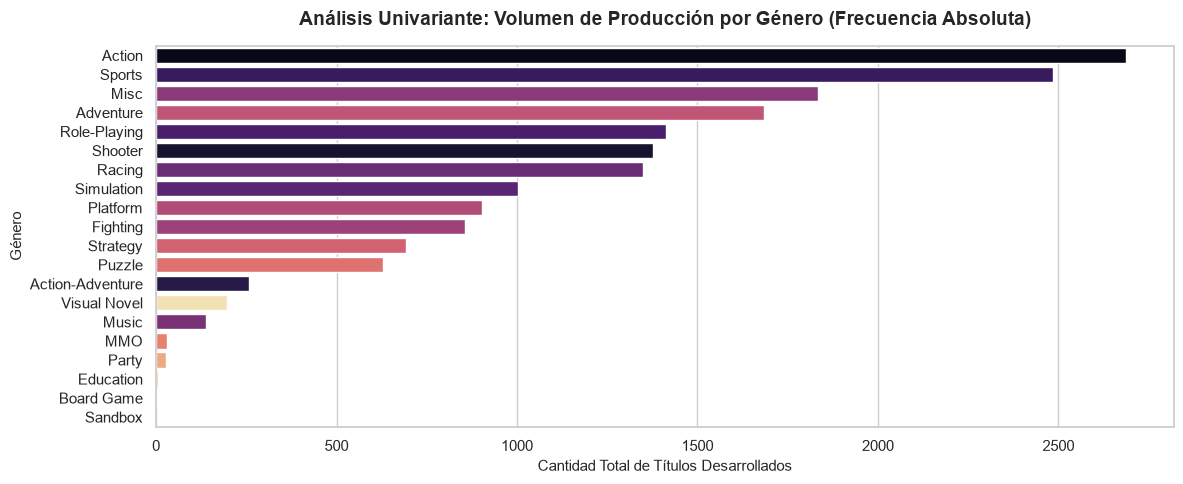

In [9]:
plt.figure(figsize=(12, 5))

# Conteo puro de registros por categoría (frecuencia simple)
order_genres = df["genre"].value_counts().index
sns.countplot(data=df, y="genre", order=order_genres, palette="magma", hue="genre", legend=False)

plt.title(
    "Análisis Univariante: Volumen de Producción por Género (Frecuencia Absoluta)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Cantidad Total de Títulos Desarrollados", fontsize=11)
plt.ylabel("Género", fontsize=11)

plt.tight_layout()
plt.show()

### Gracias a esta gráfica podemos apreciar que los géneros de acción, deportes y simuladores, son los líderes en cuanto a producción.

## Distribución y sesgo de ventas.

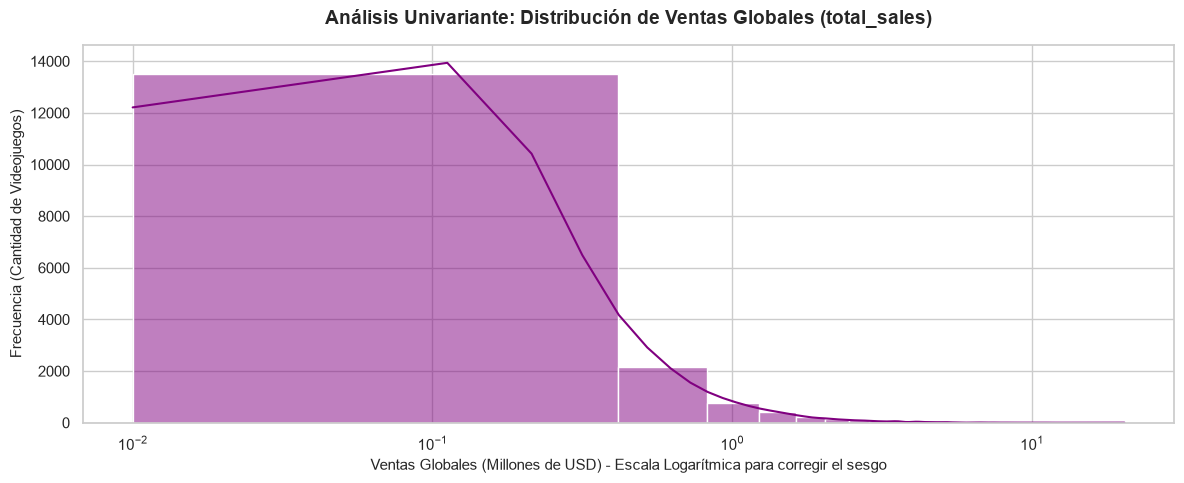

--- MÉTRICAS DE DISTRIBUCIÓN ---
Media de ventas: $0.38M
Mediana de ventas: $0.14M
Asimetría (Skewness): 8.55


In [10]:
# Configuración del gráfico de la distribución de la variable objetivo
plt.figure(figsize=(12, 5))

# Histograma con curva de densidad (KDE)
sns.histplot(data=df, x="total_sales", bins=50, kde=True, color="purple")

plt.title(
    "Análisis Univariante: Distribución de Ventas Globales (total_sales)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ventas Globales (Millones de USD)", fontsize=11)
plt.ylabel("Frecuencia (Cantidad de Videojuegos)", fontsize=11)

# Aplicar escala logarítmica para visualizar la distribución real debido al alto sesgo a la derecha
plt.xscale("log")
plt.xlabel(
    "Ventas Globales (Millones de USD) - Escala Logarítmica para corregir el sesgo",
    fontsize=11,
)

plt.tight_layout()
plt.show()

# Métricas estadísticas univariantes de la variable
print("--- MÉTRICAS DE DISTRIBUCIÓN ---")
print(f"Media de ventas: ${df['total_sales'].mean():.2f}M")
print(f"Mediana de ventas: ${df['total_sales'].median():.2f}M")
print(f"Asimetría (Skewness): {df['total_sales'].skew():.2f}")

### La gran mayoría de los videojuegos (más de 13,000 títulos) se concentran en el rango de ventas más bajo (por debajo de 1 millón de USD). A medida que las ventas aumentan hacia los 10 millones o más, la cantidad de juegos cae de forma drástica, reflejando un mercado dominado por una enorme cantidad de títulos de bajo éxito comercial y una "larga cola" de muy pocos éxitos de ventas (blockbusters).

## Fecuencia de lanzamientos por plataforma.

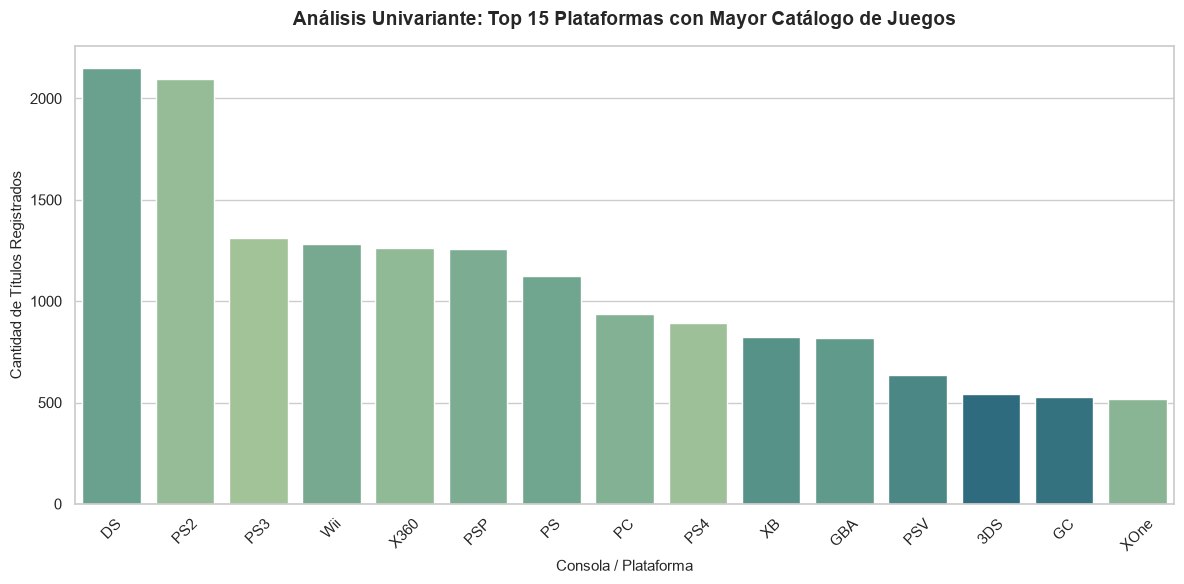

In [11]:
plt.figure(figsize=(12, 6))

# Conteo puro del Top 15 consolas con más juegos en el catálogo
order_consoles = df["console"].value_counts().head(15).index
sns.countplot(
    data=df, x="console", order=order_consoles, palette="crest", hue="console", legend=False
)

plt.title(
    "Análisis Univariante: Top 15 Plataformas con Mayor Catálogo de Juegos",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Consola / Plataforma", fontsize=11)
plt.ylabel("Cantidad de Títulos Registrados", fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Líderes indiscutibles: La Nintendo DS y la PlayStation 2 (PS2) encabezan el ranking de forma destacada, siendo las únicas plataformas que superan los 2,000 títulos registrados.

# 6. Análisis Bivariante.

## Top plataformas por ventas.

findfont: Failed to find font weight semibold, now using 700.


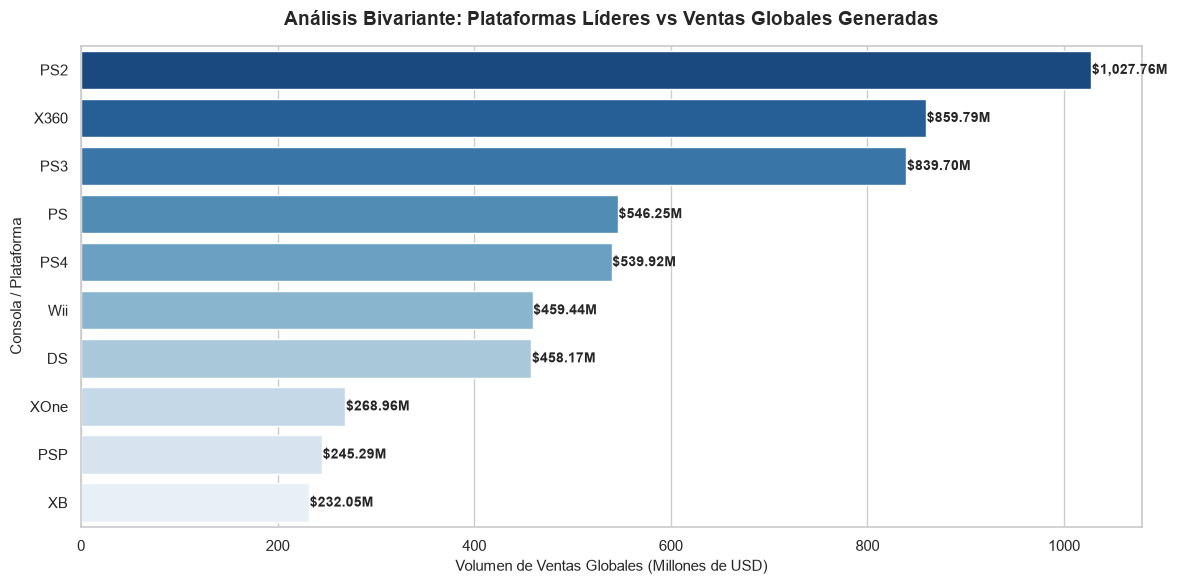

In [12]:
plt.figure(figsize=(12, 6))

# Cruza dos variables: 'console' (Categórica) vs 'total_sales' (Numérica)
top_consoles = (
    df.groupby("console")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=top_consoles,
    x="total_sales",
    y="console",
    palette="Blues_r",
    hue="console",
    legend=False,
)

plt.title(
    "Análisis Bivariante: Plataformas Líderes vs Ventas Globales Generadas",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Volumen de Ventas Globales (Millones de USD)", fontsize=11)
plt.ylabel("Consola / Plataforma", fontsize=11)

for index, value in enumerate(top_consoles["total_sales"]):
    plt.text(
        value + 0.5,
        index,
        f"${value:,.2f}M",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="semibold",
    )

plt.tight_layout()
plt.show()

### Gracias a esta gráfica podemos apreciar que la marca playStation domina el gráfico con tres de sus plataformas en el top 5, destacando históricamente la ps2

## Participación por géneros

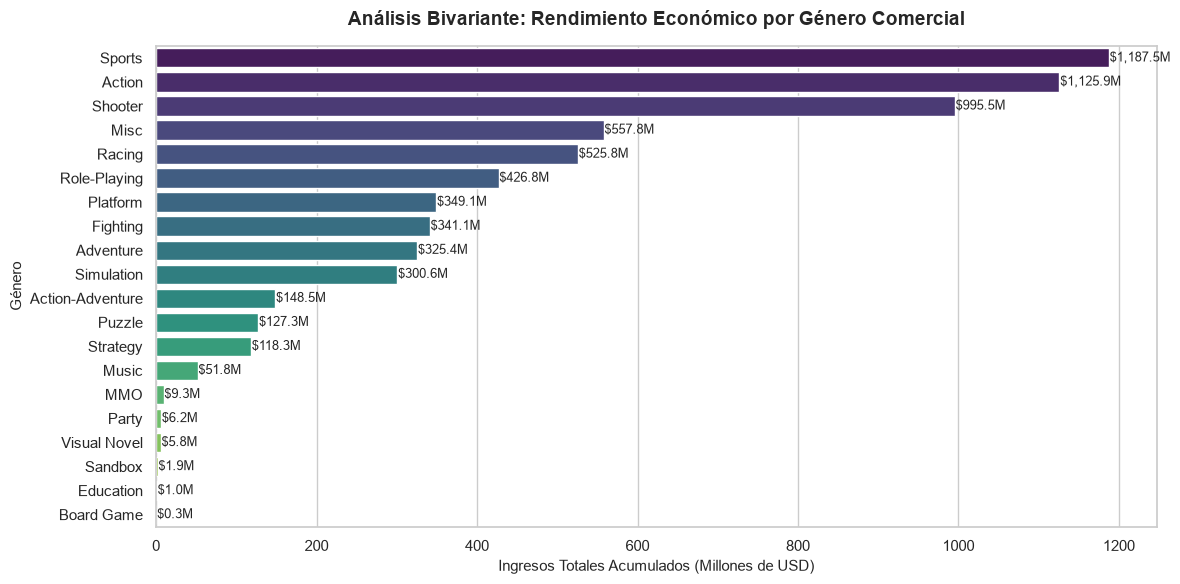

In [13]:
plt.figure(figsize=(12, 6))

# Cruza dos variables: 'genre' (Categórica) vs 'total_sales' (Numérica)
ventas_genero = (
    df.groupby("genre")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=ventas_genero,
    x="total_sales",
    y="genre",
    palette="viridis",
    hue="genre",
    legend=False,
)

plt.title(
    "Análisis Bivariante: Rendimiento Económico por Género Comercial",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ingresos Totales Acumulados (Millones de USD)", fontsize=11)
plt.ylabel("Género", fontsize=11)

for index, value in enumerate(ventas_genero["total_sales"]):
    plt.text(value + 1.0, index, f"${value:,.1f}M", va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

### En esta gráfica podemos apreciar como los tres primeros géneros dominan drásticamente los ingresos acumulados.

## Top publishers

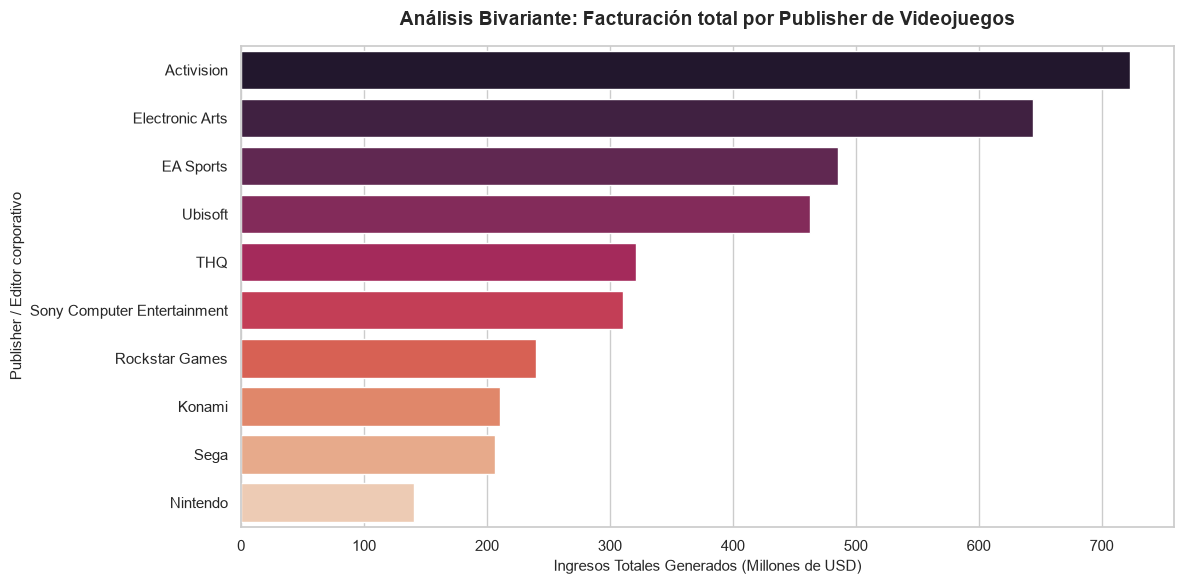

In [14]:
plt.figure(figsize=(12, 6))

# Cruza dos variables: 'publisher' (Categórica) vs 'total_sales' (Numérica)
df_pub_filtered = df[df["publisher"].str.lower() != "unknown"]
top_publishers = (
    df_pub_filtered.groupby("publisher")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=top_publishers,
    x="total_sales",
    y="publisher",
    palette="rocket",
    hue="publisher",
    legend=False,
)

plt.title(
    "Análisis Bivariante: Facturación total por Publisher de Videojuegos",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ingresos Totales Generados (Millones de USD)", fontsize=11)
plt.ylabel("Publisher / Editor corporativo", fontsize=11)

plt.tight_layout()
plt.show()

### En este gráfico podemos ver que activision es el editor con mayor facturación.

## Críticas vs ventas

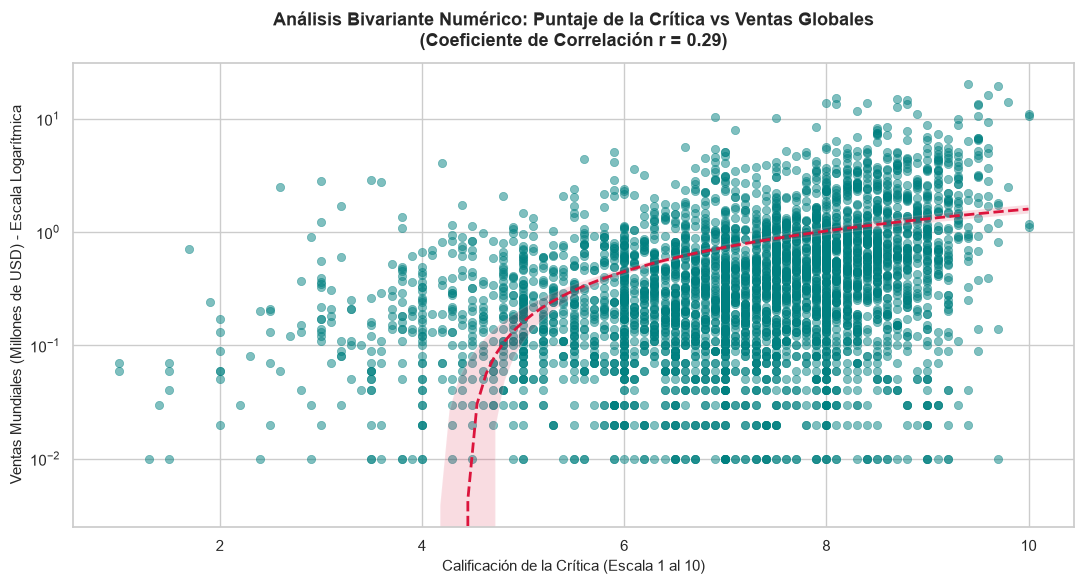

In [15]:
df_critics = df[df["critic_score"].notnull() & (df["critic_score"] > 0)]

plt.figure(figsize=(11, 6))

# Cruza dos variables continuas numéricas: 'critic_score' vs 'total_sales'
sns.scatterplot(
    data=df_critics,
    x="critic_score",
    y="total_sales",
    alpha=0.5,
    color="teal",
    edgecolor=None,
)
sns.regplot(
    data=df_critics,
    x="critic_score",
    y="total_sales",
    scatter=False,
    color="crimson",
    line_kws={"linewidth": 2, "linestyle": "--"},
)

correlacion = df_critics["critic_score"].corr(df_critics["total_sales"])

plt.title(
    f"Análisis Bivariante Numérico: Puntaje de la Crítica vs Ventas Globales\n(Coeficiente de Correlación r = {correlacion:.2f})",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Calificación de la Crítica (Escala 1 al 10)", fontsize=11)
plt.yscale("log")
plt.ylabel(
    "Ventas Mundiales (Millones de USD) - Escala Logarítmica", fontsize=11
)

plt.tight_layout()
plt.show()

### La gráfica de la imagen demuestra que una buena calificación de la crítica ayuda a empujar las ventas hacia arriba, pero el éxito comercial masivo depende de muchos otros factores externos (como el marketing, el reconocimiento de la marca, las tendencias del mercado o el hype) que no se reflejan en una simple nota de los analistas.

## Evolución de años.

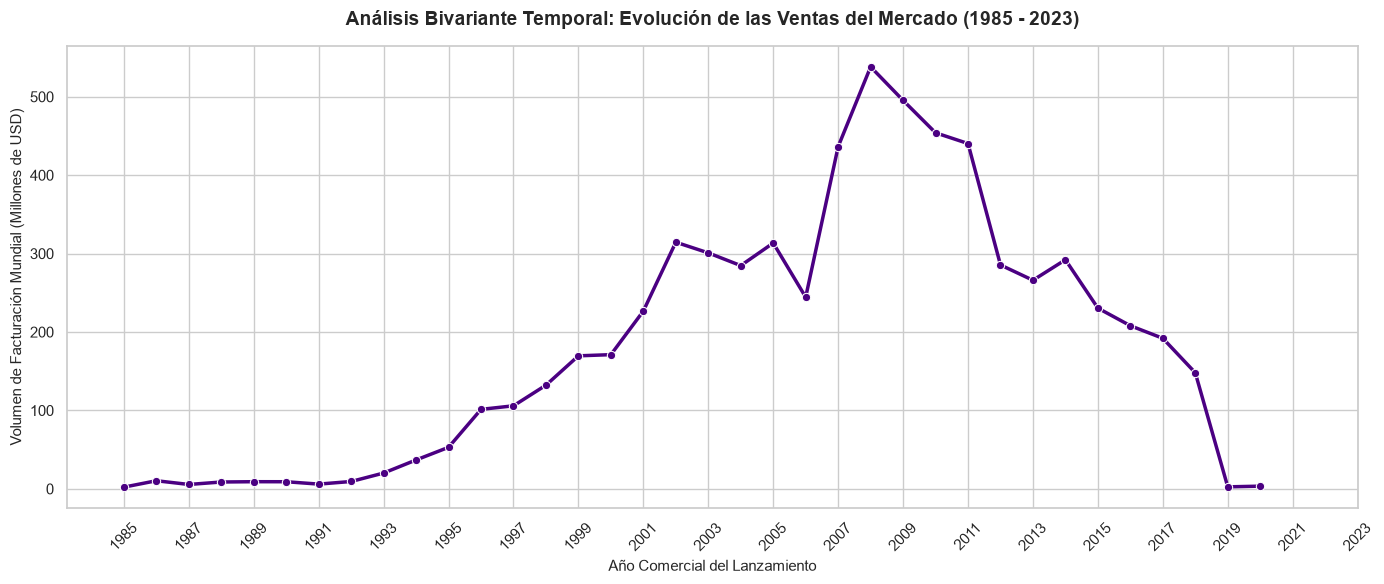

In [16]:
plt.figure(figsize=(14, 6))

# Cruza dos variables: 'year' (Temporal/Entero) vs 'total_sales' (Numérica)
df_temporal = df[(df["year"].notnull()) & (df["year"] >= 1985) & (df["year"] <= 2023)]
evolucion_anual = (
    df_temporal.groupby("year")["total_sales"].sum().reset_index()
)

sns.lineplot(
    data=evolucion_anual,
    x="year",
    y="total_sales",
    marker="o",
    linewidth=2.5,
    color="indigo",
)

plt.title(
    "Análisis Bivariante Temporal: Evolución de las Ventas del Mercado (1985 - 2023)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Año Comercial del Lanzamiento", fontsize=11)
plt.ylabel("Volumen de Facturación Mundial (Millones de USD)", fontsize=11)
plt.xticks(ticks=np.arange(1985, 2024, 2), rotation=45)

plt.tight_layout()
plt.show()

### Éste gráfico de líneas muestra la evolución de la facturación mundial (en millones de USD) entre 1985 y 2023, la cual se resume en cuatro etapas clave:

- 1985–1992 (Estancamiento): Ventas iniciales prácticamente nulas, manteniéndose casi en $0.

- 1993–2002 (Crecimiento): Subida constante y sostenida hasta superar los $300 millones.

- 2008 (Pico Máximo): El mercado alcanza su récord histórico superando los $540 millones.

- 2009–2020 (Colapso): Caída libre progresiva hasta regresar a niveles cercanos a cero en 2019-2020, año en el que se interrumpen los registros visuales.

## Segmentación de ventas por región.

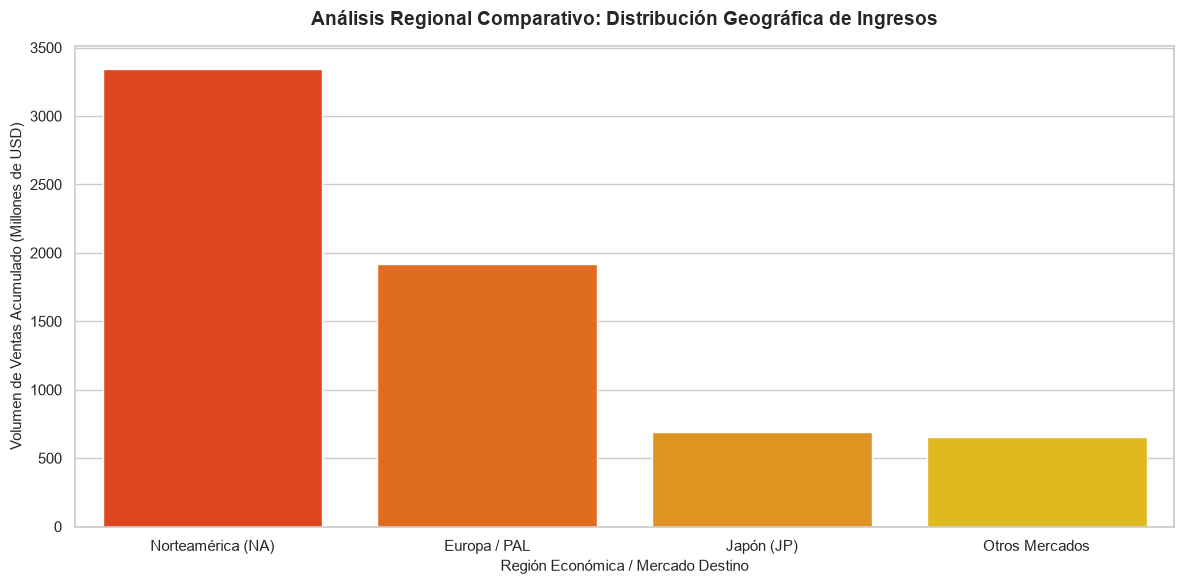

In [17]:
plt.figure(figsize=(12, 6))

# Cruza múltiples variables geográficas contra el volumen total de ingresos
regiones = {
    "Norteamérica (NA)": df["na_sales"].sum(),
    "Europa / PAL": df["pal_sales"].sum(),
    "Japón (JP)": df["jp_sales"].sum(),
    "Otros Mercados": df["other_sales"].sum(),
}

df_regiones = pd.DataFrame(list(regiones.items()), columns=["Region", "Ventas"])
df_regiones = df_regiones.sort_values(by="Ventas", ascending=False)

sns.barplot(
    data=df_regiones,
    x="Region",
    y="Ventas",
    palette="autumn",
    hue="Region",
    legend=False,
)

plt.title(
    "Análisis Regional Comparativo: Distribución Geográfica de Ingresos",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Región Económica / Mercado Destino", fontsize=11)
plt.ylabel("Volumen de Ventas Acumulado (Millones de USD)", fontsize=11)

plt.tight_layout()
plt.show()

### Norteamérica es el principal motor de ingresos, duplicando casi a Europa y superando por más de cuatro veces a los mercados asiáticos y secundarios.

C:\Users\crazy\AppData\Local\Temp\ipykernel_25208\4087899454.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(df_monthly["month_es"], rotation=40)
C:\Users\crazy\AppData\Local\Temp\ipykernel_25208\4087899454.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(df_monthly["month_es"], rotation=40)


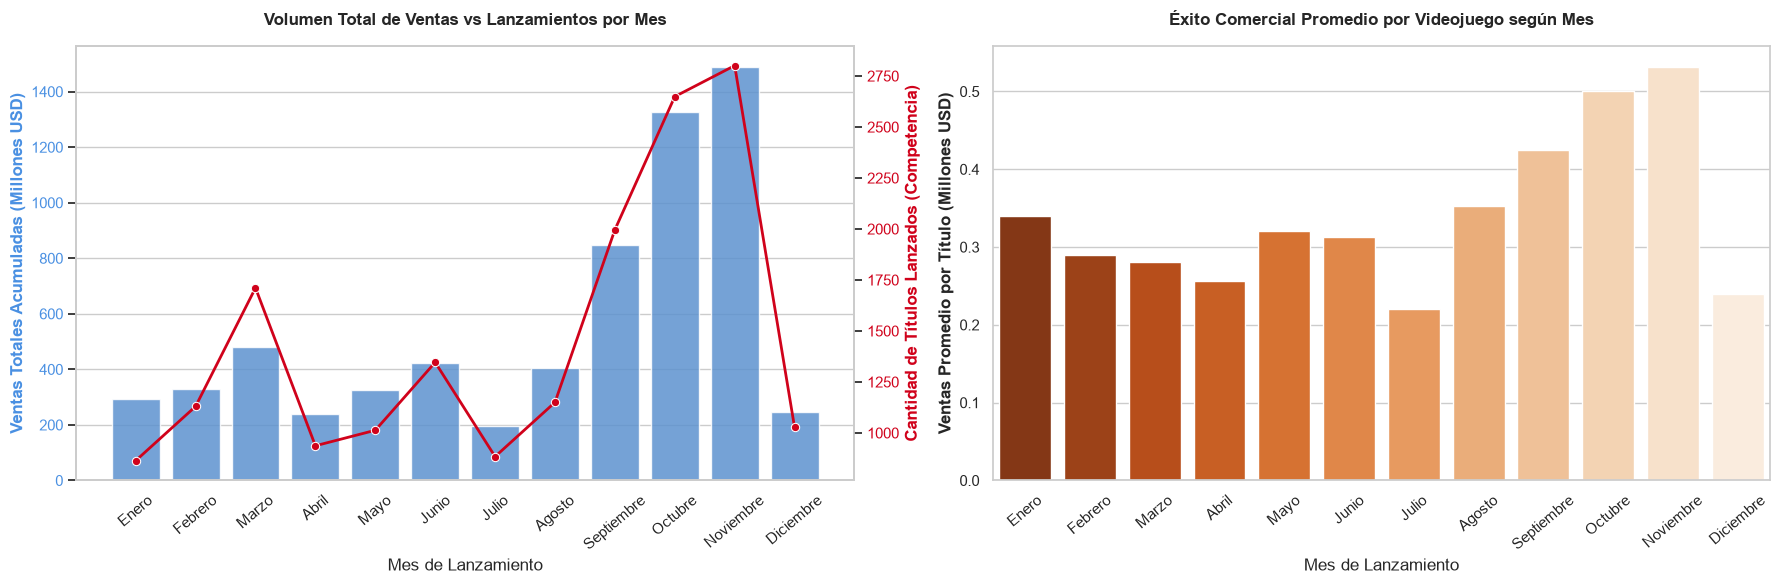

-> Mayor Volumen de Mercado (Saturado): Noviembre ($1490.30 M USD)
-> Ventana Estratégica de Alta Eficiencia: Noviembre ($0.5321 M USD promedio por juego)


In [18]:
if 'release_date' in df.columns:
    # Filtrar registros que tengan fechas y ventas válidas
    df_season = df[df["release_date"].notnull() & df["total_sales"].notnull()].copy()
    df_season["release_date"] = pd.to_datetime(df_season["release_date"], errors='coerce')
    df_season = df_season[df_season["release_date"].notnull()]
    
    # Extraer el número del mes
    df_season["month_num"] = df_season["release_date"].dt.month
    
    # Mapeo a nombres en español para mejorar la estética del reporte
    meses_es = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
                7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
    df_season["month_es"] = df_season["month_num"].map(meses_es)
    
    # Agrupación bivariante: Mes vs (Suma de Ventas, Conteo de Títulos y Media de Ventas)
    df_monthly = df_season.groupby(["month_num", "month_es"]).agg(
        total_sales_millions=("total_sales", "sum"),
        titles_launched=("total_sales", "count"),
        avg_sales_per_title=("total_sales", "mean")
    ).reset_index().sort_values("month_num")
    
    if not df_monthly.empty:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Subplot A (Bivariante Doble): Volumen Total de Ventas vs Lanzamientos por Mes
        color_bar = "#4a90e2"
        color_line = "#d0021b"
        sns.barplot(data=df_monthly, x="month_es", y="total_sales_millions", ax=axes[0], color=color_bar, alpha=0.85)
        axes[0].set_title("Volumen Total de Ventas vs Lanzamientos por Mes", fontweight="bold", pad=15)
        axes[0].set_xlabel("Mes de Lanzamiento")
        axes[0].set_ylabel("Ventas Totales Acumuladas (Millones USD)", color=color_bar, fontweight="bold")
        axes[0].tick_params(axis='y', labelcolor=color_bar)
        axes[0].set_xticklabels(df_monthly["month_es"], rotation=40)
        
        # Eje Y secundario para la competencia (Lanzamientos)
        ax0_2 = axes[0].twinx()
        sns.lineplot(data=df_monthly, x="month_es", y="titles_launched", ax=ax0_2, color=color_line, marker="o", linewidth=2, sort=False)
        ax0_2.set_ylabel("Cantidad de Títulos Lanzados (Competencia)", color=color_line, fontweight="bold")
        ax0_2.tick_params(axis='y', labelcolor=color_line)
        ax0_2.grid(False)
        
        # Subplot B (Bivariante Puro): Eficiencia Unitaria (Mes vs Venta Promedio)
        sns.barplot(data=df_monthly, x="month_es", y="avg_sales_per_title", ax=axes[1], palette="Oranges_r", hue="month_es", legend=False)
        axes[1].set_title("Éxito Comercial Promedio por Videojuego según Mes", fontweight="bold", pad=15)
        axes[1].set_xlabel("Mes de Lanzamiento")
        axes[1].set_ylabel("Ventas Promedio por Título (Millones USD)", fontweight="bold")
        axes[1].set_xticklabels(df_monthly["month_es"], rotation=40)
        
        plt.tight_layout()
        plt.show()
        
        # KPIs Ejecutivos impresos en consola
        top_mes_vol = df_monthly.loc[df_monthly["total_sales_millions"].idxmax()]
        top_mes_eff = df_monthly.loc[df_monthly["avg_sales_per_title"].idxmax()]
        print(f"-> Mayor Volumen de Mercado (Saturado): {top_mes_vol['month_es']} (${top_mes_vol['total_sales_millions']:.2f} M USD)")
        print(f"-> Ventana Estratégica de Alta Eficiencia: {top_mes_eff['month_es']} (${top_mes_eff['avg_sales_per_title']:.4f} M USD promedio por juego)")
    else:
        print("[INFO] No hay suficientes datos con fechas válidas para procesar la estacionalidad.")
else:
    print("[INFO] La columna 'release_date' no está disponible para este análisis.")

## Lanzamiento por fecha de títulos masivos.

C:\Users\crazy\AppData\Local\Temp\ipykernel_25208\901721846.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(orden_meses, rotation=40)
findfont: Failed to find font weight semibold, now using 700.


=== IDENTIFICACIÓN DE TÍTULOS MASIVOS ===
• Umbral para ser considerado un juego masivo (Top 5%): Obras con más de $1.44M de copias/ventas.
• Cantidad de títulos masivos identificados para el análisis: 884 juegos.




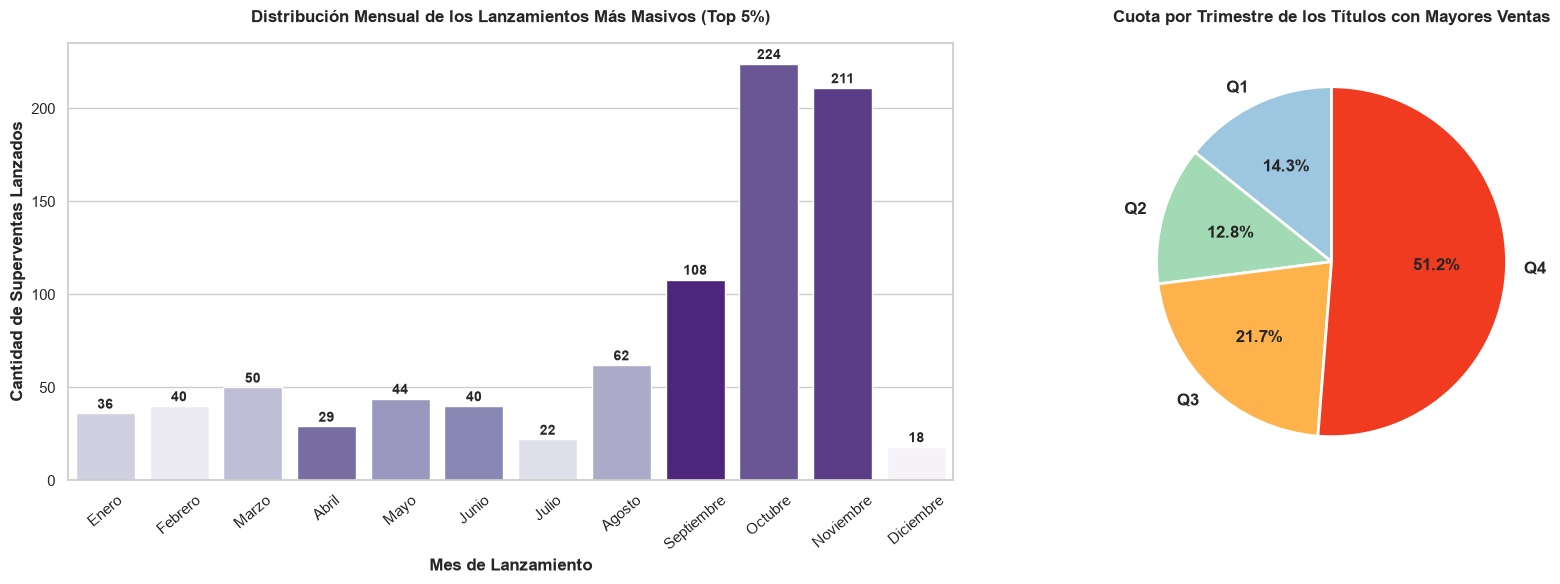


=== MUESTRA DE CONTROL: TOP 5 JUEGOS MÁS MASIVOS ENCONTRADOS ===
                      title console  year  total_sales   month_es
         Grand Theft Auto V     PS3  2013        20.32 Septiembre
         Grand Theft Auto V     PS4  2014        19.39  Noviembre
Grand Theft Auto: Vice City     PS2  2002        16.15    Octubre
         Grand Theft Auto V    X360  2013        15.86 Septiembre
  Call of Duty: Black Ops 3     PS4  2015        15.09  Noviembre


In [19]:
if 'release_date' in df.columns and 'total_sales' in df.columns:
    # 1. Filtrar registros con fechas y ventas válidas
    df_hits = df[df["release_date"].notnull() & df["total_sales"].notnull()].copy()
    df_hits["release_date"] = pd.to_datetime(df_hits["release_date"], errors='coerce')
    df_hits = df_hits[df_hits["release_date"].notnull()]
    
    # 2. Extraer el mes y el trimestre (Quarter) de lanzamiento
    df_hits["month_num"] = df_hits["release_date"].dt.month
    df_hits["quarter"] = "Q" + df_hits["release_date"].dt.quarter.astype(str)
    
    meses_es = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
                7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
    df_hits["month_es"] = df_hits["month_num"].map(meses_es)
    
    # 3. Definir el umbral del Top 5% de juegos más masivos del dataset
    umbral_top_5 = df_hits["total_sales"].quantile(0.95)
    
    # Filtrar el subconjunto de "Títulos Masivos"
    df_blockbusters = df_hits[df_hits["total_sales"] >= umbral_top_5]
    
    print(f"=== IDENTIFICACIÓN DE TÍTULOS MASIVOS ===")
    print(f"• Umbral para ser considerado un juego masivo (Top 5%): Obras con más de ${umbral_top_5:.2f}M de copias/ventas.")
    print(f"• Cantidad de títulos masivos identificados para el análisis: {df_blockbusters.shape[0]} juegos.")
    print("\n" + "="*60 + "\n")
    
    # 4. Configurar orden cronológico estricto para evitar problemas alfabéticos
    orden_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                   "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
    orden_trimestres = ["Q1", "Q2", "Q3", "Q4"]
    
    # 5. Diseño de Gráficas Coorporativas
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfica A: Distribución de los Títulos Masivos por Mes
    sns.countplot(data=df_blockbusters, x="month_es", order=orden_meses, palette="Purples_r", ax=axes[0], hue="month_es", legend=False)
    axes[0].set_title("Distribución Mensual de los Lanzamientos Más Masivos (Top 5%)", fontweight="bold", pad=15, fontsize=12)
    axes[0].set_xlabel("Mes de Lanzamiento", fontweight="semibold")
    axes[0].set_ylabel("Cantidad de Superventas Lanzados", fontweight="semibold")
    axes[0].set_xticklabels(orden_meses, rotation=40)
    
    # Anotar cantidades exactas arriba de cada barra mensual
    for p in axes[0].patches:
        height = p.get_height()
        if height > 0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height + 1),
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Gráfica B: Cuota de Títulos Masivos por Trimestre Comercial (Quarter)
    conteo_q = df_blockbusters["quarter"].value_counts().reindex(orden_trimestres)
    axes[1].pie(conteo_q, labels=conteo_q.index, autopct='%1.1f%%', startangle=90, 
               colors=["#9dc6e0", "#a1dab4", "#feb24c", "#f03b20"], 
               textprops={'fontsize': 12, 'fontweight': 'bold'},
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title("Cuota por Trimestre de los Títulos con Mayores Ventas", fontweight="bold", pad=15, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 6. Muestra de control ejecutiva de los juegos que entraron en esta categoría
    print("\n=== MUESTRA DE CONTROL: TOP 5 JUEGOS MÁS MASIVOS ENCONTRADOS ===")
    columnas_muestra = [c for c in ['title', 'name', 'console', 'platform', 'year', 'total_sales', 'month_es'] if c in df_blockbusters.columns]
    print(df_blockbusters.sort_values(by="total_sales", ascending=False)[columnas_muestra].head(5).to_string(index=False))

else:
    print("[INFO] No se disponen de las columnas 'release_date' y 'total_sales' requeridas para este análisis.")

### Compañías VS Géneros.

findfont: Failed to find font weight semibold, now using 700.


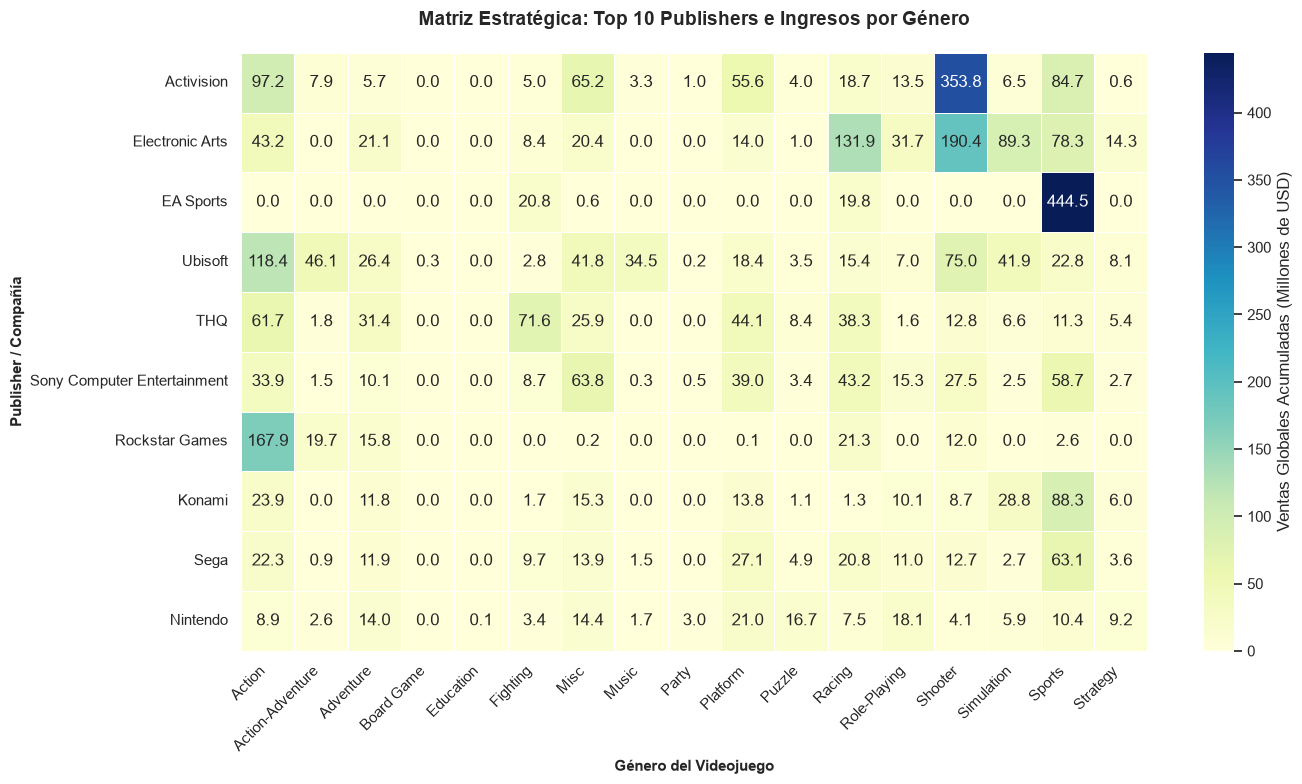

In [20]:
# Filtrar registros válidos y publishers conocidos
df_pub_genre = df[(df["publisher"].str.lower() != "unknown") & (df["total_sales"] > 0)]

# 1. Identificar de forma dinámica quiénes son el Top 10 de Publishers con más ventas totales
top_10_publishers = df_pub_genre.groupby("publisher")["total_sales"].sum().nlargest(10).index

# 2. Filtrar el DataFrame original solo con este Top 10
df_top_pub = df_pub_genre[df_pub_genre["publisher"].isin(top_10_publishers)]

# 3. Crear una tabla pivote (Matriz) que cruce Publishers (filas) y Géneros (columnas) sumando ventas
matriz_pub_genre = df_top_pub.pivot_table(
    index="publisher", 
    columns="genre", 
    values="total_sales", 
    aggfunc="sum"
).fillna(0)

# Reordenar las filas de la matriz para que el publisher número 1 quede arriba
matriz_pub_genre = matriz_pub_genre.loc[top_10_publishers]

# 4. Graficar el Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 8))
sns.heatmap(
    matriz_pub_genre, 
    cmap="YlGnBu", 
    annot=True, 
    fmt=".1f", 
    linewidths=.5, 
    cbar_kws={'label': 'Ventas Globales Acumuladas (Millones de USD)'}
)

plt.title("Matriz Estratégica: Top 10 Publishers e Ingresos por Género", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Género del Videojuego", fontsize=11, fontweight="semibold")
plt.ylabel("Publisher / Compañía", fontsize=11, fontweight="semibold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### No basta con saber qué publisher factura más; necesitamos entender su estrategia de portafolio. Utilizaremos un **Mapa de Calor (Heatmap)** cruzando el Top 10 de Publishers con los principales géneros del mercado. Cada celda muestra los ingresos acumulados, permitiendo identificar de un vistazo el nicho o la especialización de cada gigante corporativo.